# Example 1: SISO Plant Step Response

This example provides a brief introduction to the **Akson** package. System dynamics are constructed from LTI state-space matrices, and the step response is computed using the library's tools.

## Imports

The required packages are imported as follows. **Akson** provides the core functionality, `torch` is used for defining state-space system matrices, and `matplotlib` handles plotting.

In [1]:
import akson
import torch
import matplotlib.pyplot as plt

## Defining the System Dynamics

The LTI state-space system matrices are specified as torch tensors. Four $1 \times 1$ matrices are defined for a simple SISO state-space system:

In [2]:
A = torch.tensor([[-1.0]], dtype=torch.float64)
B = torch.tensor([[1.0]], dtype=torch.float64)
C = torch.tensor([[1.0]], dtype=torch.float64)
D = torch.tensor([[0.0]], dtype=torch.float64)

These matrices describe a state-space system governed by the following equations:
$$
\begin{align}
\dot{x} = Ax + Bu \\
y = Cx + Du
\end{align}
$$

The linear system dynamics object is constructed from these matrices using the `from_linear` static method:

In [3]:
system_dynamics = akson.StateSpaceDynamics.from_linear(A, B, C, D)

## Computing the Step Response

The duration of the step response must be specified. The ODE solver step size need not be provided; it is selected automatically within the stability region of the solver chosen for this system:

In [4]:
t, y = system_dynamics.step_response(duration=8.0)

The timepoints tensor has the shape `[number of points]`. The step response tensor has the shape `[number of points, number of outputs, number of inputs]`. The actual shapes are printed below:

In [5]:
print("t shape:", t.shape)
print("y shape:", y.shape)

t shape: torch.Size([7])
y shape: torch.Size([7, 1, 1])


The step response is plotted below:

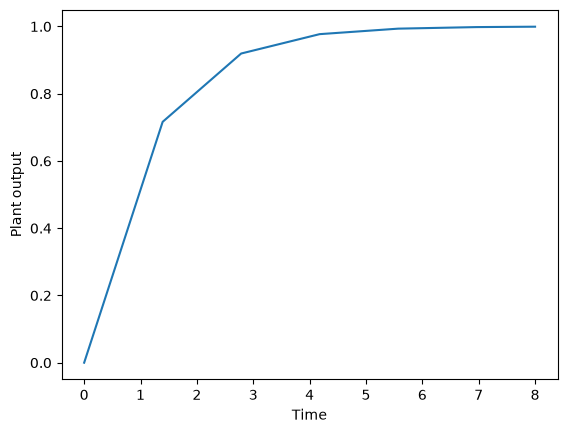

In [6]:
plt.plot(t, y[:, 0, 0])
plt.xlabel("Time")
plt.ylabel("Plant output")
plt.show()

## Improving Output Resolution

Automatic solver selection is based on stability rather than output resolution. For finer resolution, a smaller step size may be specified manually. The step response is recomputed and plotted at improved resolution below:

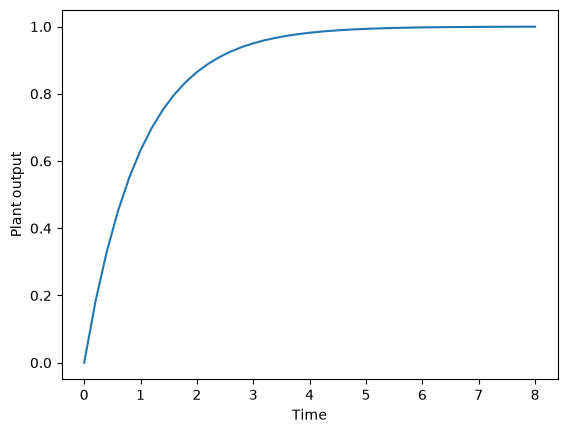

In [7]:
t, y = system_dynamics.step_response(duration=8.0, step_size=0.2)
plt.plot(t, y[:, 0, 0])
plt.xlabel("Time")
plt.ylabel("Plant output")
plt.show()